# **Chapter 1 - Firing Rates & Spike Statistics**

## **Question 1** 
**Generate spikes for 10 s (or longer if you want better statistics) using
a Poisson spike generator with a constant rate of 100 Hz, and record
their times of occurrence. Compute the coefficient of variation of the
interspike intervals, and the Fano factor for spike counts obtained
over counting intervals ranging from 1 to 100 ms. Plot the interspike
interval histogram.**

### Generating the Poisson Spike Sequence
A Poisson spike sequence is generated with the following formula: $$\Delta t = \frac{-\ln{x_{rand}}}{r} \tag{eq 1}$$ where "r" is the rate of the underlying distribution.

In [2]:
###Importing libraries###
import numpy as np
import matplotlib.pyplot as plt

###Setting variables###
r = 100.0 #underlying rate of distribution, in Hertz
times = [0.0] #list of time values, each corresponding to a spike
T = 10.0 #length of spike sequence generated, in seconds

###Creating list of spikes###
def find_delta_t(x_rand, rate):
    return -1*(np.log(x_rand)) / rate #finding delta_t according to (eq 1)

while times[-1] <= T: #Limiting the spike sequence to a certain time limit, defined by "T"
    #creating a spike at the previous time + delta_t
    times.append(times[-1] + find_delta_t(np.random.rand(), r)) 

#deleting the 0.0 at the start of the array and the last value, which is past T seconds
times = times[1:-1] 

### Plotting the Interspike Interval Histogram

(0.0, 100.0)

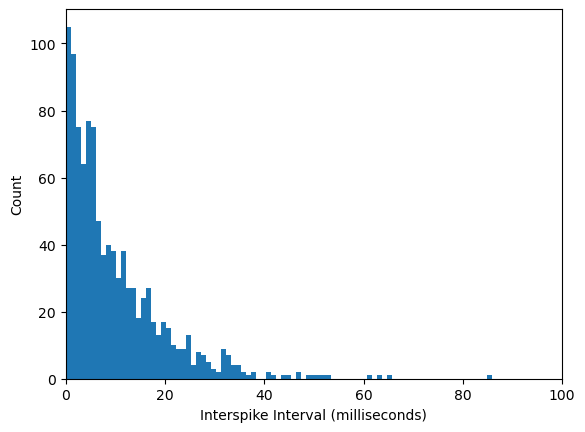

In [3]:
ISI = [] #creating an empty array for the interspike intervals

#iterating through every spike to calculate the time to the next spike
for i in range(len(times) - 1):
    ISI.append((times[i + 1] - times[i]) * 1000) #multiplying by 1000 to convert from s to ms


plt.hist(ISI, bins=99, range=(0,100))
plt.xlabel("Interspike Interval (milliseconds)")
plt.ylabel("Count")
plt.xlim(0,100)

### Calculating Coefficient of Variation & Fano Factor
Coefficient of variation of a Poisson process is calculated via the standard deviation divided by the mean of the interspike interval distribution. \
\
Fano factor of a Poisson process is calculated via the variance divided by the mean of the spike count distribution. \
\
Thus, for any renewal process, the Fano factor should approach the square of the coefficient of variation.

In [4]:
C_v = np.std(ISI) / np.mean(ISI) #Calculating coefficient of variation
print(f"Coefficient of variation: {C_v}")

#Calculating Fano factor
bin_sizes = [0.001, 0.01, 0.1]  # 1, 10, 100 ms bins
for i in bin_sizes:
    counts, _ = np.histogram(times, bins=np.arange(0, T + i, i))
    print(f"Fano Factor for bins of {i * 1000} ms: {np.var(counts) / np.mean(counts)}")

Coefficient of variation: 1.0099964019101184
Fano Factor for bins of 1.0 ms: 1.0050218749999997
Fano Factor for bins of 10.0 ms: 1.00725
Fano Factor for bins of 100.0 ms: 0.8869531250000001


## **Question 2**
**Add a refractory period to the Poisson spike generator by allowing the firing rate to depend on time. Initially, set the firing rate to a constant value, $r(t) = r_0$. After every spike, set $r(t)$ to 0, and then allow it to recover exponentially back to $r_0$ with a time constant $\tau_{ref}$ that controls the refractory recovery rate. In other words, have $r(t)$ obey the equation $$\tau_{\text{ref}} \frac{dr}{dt} = r_0 - r$$ except immediately after a spike, when it is set to 0. Plot the coefficient of variation as a function of $\tau_{ref}$ over the range 1 ms $\le \tau_{ref} \le$ 20 ms, and plot interspike interval histograms for a few different values of $\tau_{ref}$ in this range. Compute the Fano factor for spike counts obtained over counting intervals ranging from 1 to 100 ms for the case $\tau_{ref}$ = 10 ms.**

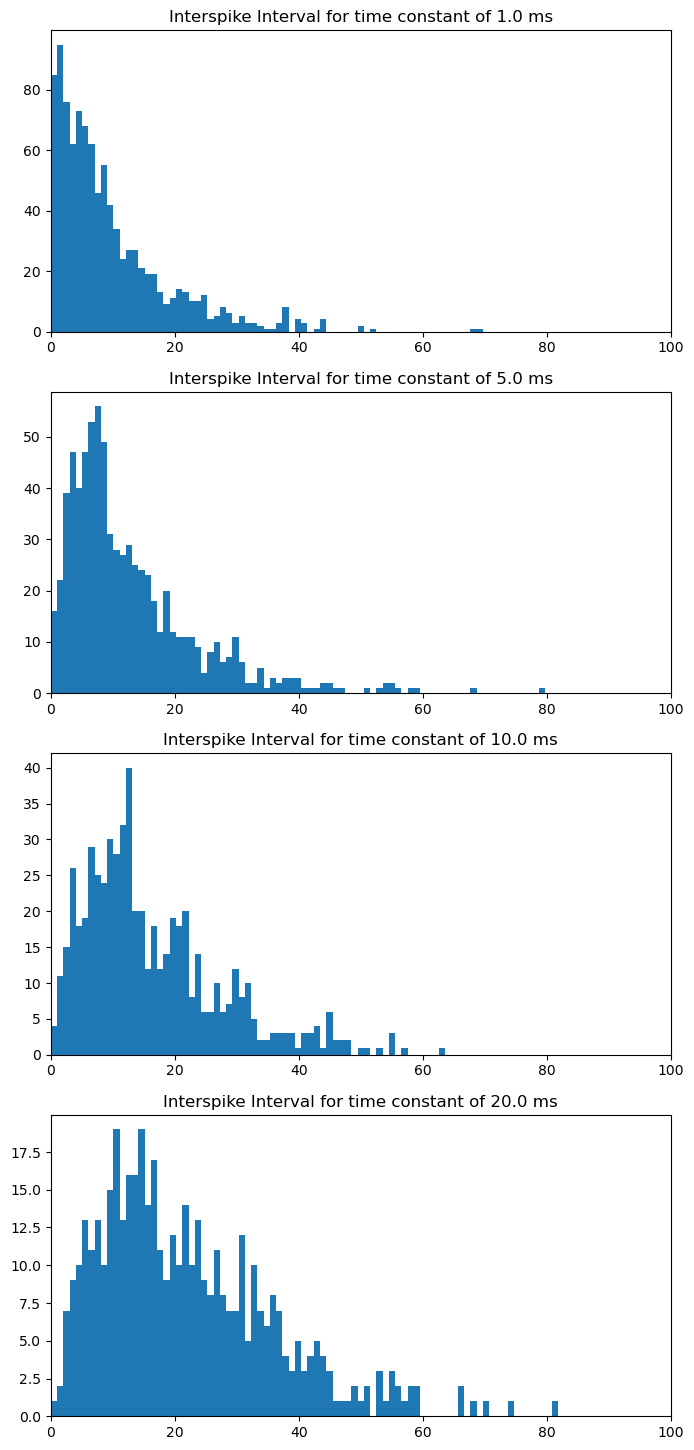

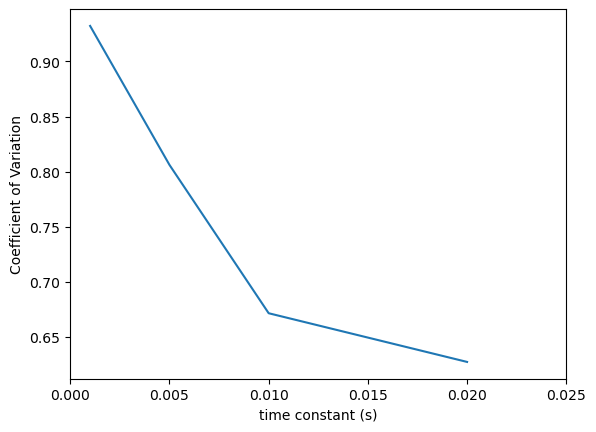

Fano Factor for bins of 1.0 ms: 0.9405 
Fano Factor for bins of 10.0 ms: 0.6402941176470589 
Fano Factor for bins of 100.0 ms: 0.33739495798319324 



In [5]:
refracted_times = []
coefficients_variation = []
time_constants = [0.001, 0.005, 0.01, 0.02]
dt = 0.001
fano_output = ""

fig, plots = plt.subplots(4,1, figsize=(8,18))

refracted_times_10 = [] #used for Question 3 later, not relevant for this question

for num in range(len(plots)):
    tau_ref = time_constants[num]
    refracted_times = []
    current_rate = r 

    for t in np.arange(0, T, dt):
        # rate recovery
        current_rate += (r - current_rate) * (dt / tau_ref)

        # probability of spike
        if np.random.rand() < current_rate * dt:
            refracted_times.append(t)
            current_rate = 0

    if tau_ref == 0.01:
        refracted_times_10 = refracted_times
        bin_sizes = [0.001, 0.01, 0.1]  # 1, 10, 100 ms bins
        for i in bin_sizes:
            counts, _ = np.histogram(refracted_times, bins=np.arange(0, T + i, i))
            fano_output += f"Fano Factor for bins of {i * 1000} ms: {np.var(counts) / np.mean(counts)} \n"  
        
    # compute ISI
    if len(refracted_times) > 1:
        ISI = np.diff(refracted_times) * 1000
    else:
        ISI = []

    plots[num].hist(ISI, bins=99, range=(0,100))
    plots[num].set_title(f"Interspike Interval for time constant of {tau_ref * 1000} ms")
    plots[num].set_xlim(0, 100)

    if len(ISI) > 0:
        coefficients_variation.append(np.std(ISI) / np.mean(ISI))
    else:
        coefficients_variation.append(0)

plt.figure()
plt.plot(time_constants, coefficients_variation)
plt.xlabel("time constant (s)")
plt.ylabel("Coefficient of Variation")
plt.xlim(0,0.025)
plt.show()

print(fano_output)

## **Question 3**
**Compute autocorrelation histograms of spike trains generated by a Poisson generator with a constant firing rate of 100 Hz, a constant firing rate of 100 Hz together with a refractory period modeled as in exercise 2 with $\tau_{ref}$ = 10 ms, and a variable firing rate: $$r(t) = 100(1 + cos(2{\bf \pi}t/25 \text{ ms})) \text{ Hz}$$Plot the histograms over a range from 0 to 100 ms.**

### Autocorrelation Function
The autocorrelation function is formally defined as $$Q_{pp}(\tau) = \frac{1}{T}\int_0^T dt \langle (\rho (t) - \langle r \rangle)(\rho (t + \tau) - \langle r \rangle) \rangle \tag{eq 2}$$ Which ends up simplifying to an average of products of the differences between the rates at every pair of spikes. This question, however, only asks for the autocorrelation histograms, meaning the only thing to be computed is the product of the differences.
\
\
Additionally, when programming, the function must be discretized, and when a delta function of spikes is used as an input, the autocorrelation function simplifies to the mean of differences between all spikes (including a spike and itself).

In [6]:
def autocorrelation_histogram(spikes):
    spikes = np.asarray(spikes)
    diffs = spikes[:, None] - spikes[None, :]
    diffs = diffs.flatten()
    return diffs

#### Poisson Generator of Constant Rate

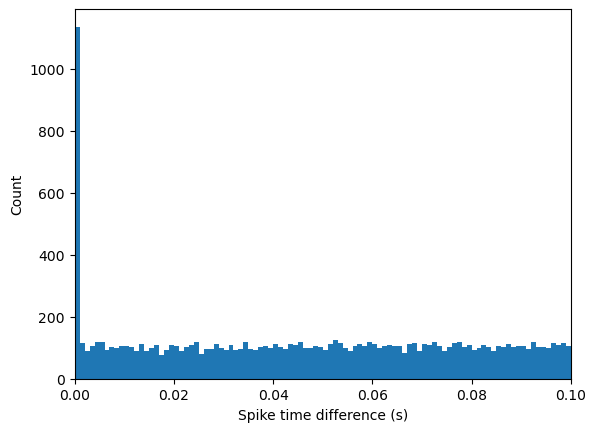

In [7]:
#Refer to Q1 for generation of "times" as a constant-rate Poisson process
plt.figure()
plt.hist(autocorrelation_histogram(times), bins=100, range=(0, 0.1))
plt.xlim(0, 0.1)
plt.xlabel("Spike time difference (s)")
plt.ylabel("Count")
plt.show()

The spike at 0ms is caused by the relative majority of comparisons between spikes being between the spike and itself, yielding a difference of 0. Because the coefficient of variation of a constant-rate Poisson process is close to 1, there is little variation between the spike time differences. Additionally, the baseline (around 200 in the graph above) is equal to: $$\frac{N^2 \Delta t}{T}, N \approx rT \tag{eq 3}$$ Thus, the expected value per histogram for our calculation is $\frac{(100*10)^2 * 0.001}{10} = 100$.

#### Poisson Generator of Refractory Rate

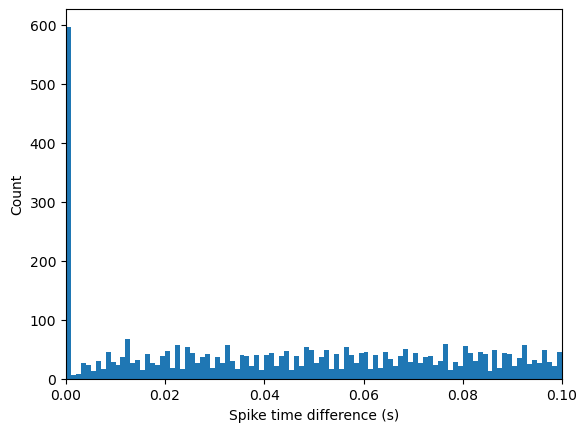

In [8]:
#Refer to Q2 for generation of "refracted_times_10" as a refractory-rate Poisson process
plt.figure()
plt.hist(autocorrelation_histogram(refracted_times_10), bins=100, range=(0, 0.1))
plt.xlim(0, 0.1)
plt.xlabel("Spike time difference (s)")
plt.ylabel("Count")
plt.show()

A Poisson generated spike train with a refractory period shows a similar  graph, but the time constant means the spike time difference is a jagged graph due to the refractory period creating a "cool-off" for refiring.

#### Poisson Generator of Variable Firing Rate

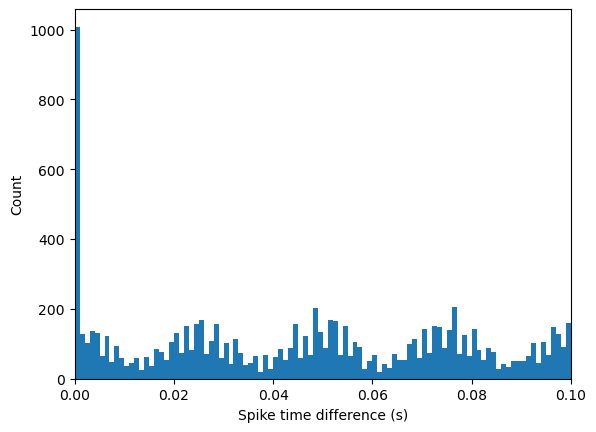

In [9]:
variable_spikes = []
for time in np.arange(0, T, dt):
    rate = 100 * (1 + np.cos(2*np.pi*time / 0.025))
    if np.random.rand() < rate * dt:
        variable_spikes.append(time)

plt.figure()
plt.hist(autocorrelation_histogram(variable_spikes), bins=100, range=(0, 0.1))
plt.xlim(0, 0.1)
plt.xlabel("Spike time difference (s)")
plt.ylabel("Count")
plt.show()

Finally, for a spike generation process that is sinusoidal in nature, the oscillations of the approximate curves give an indication that there is a rhythmic pattern to the spike train.

## **Question 4**
**Generate a Poisson spike train with a time-dependent firing rate: $$r(t) = 100(1 + \cos{2\pi t/300 \text{ ms}}) \text{ Hz}$$Approximate the firing rate from this spike train using a variable $r_{approx}$ that satisfies $$\tau_{approx} \frac{dr_{approx}}{dt} = -r_{approx}$$ except that $r_{approx} \to r_{approx} + 1/\tau_{approx}$ every time a spike occurs. Make plots of the true rate, the spike sequence generated, and the estimated rate. Experiment with a few different values of $\tau_{approx}$ in the range of 1 to 100 ms. Determine the best value of $\tau_{approx}$ by computing the average squared error of the estimate: $$\int dt(r(t)-r_{approx}(t))^2$$ for different values of $\tau_{approx}$, and finding the value of $\tau_{approx}$ that minimizes this error.**


### Spike Sequence & True Rate

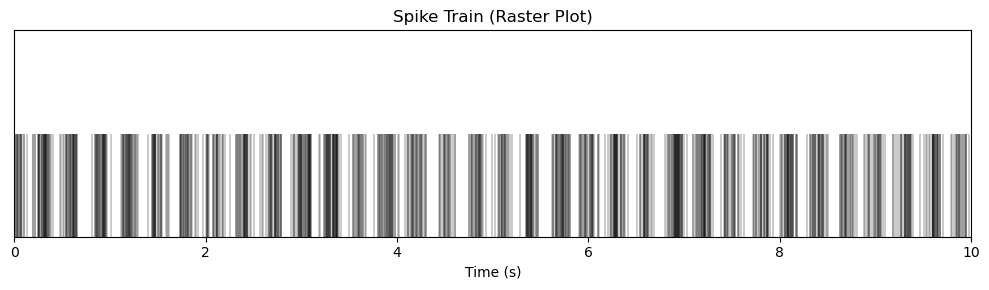

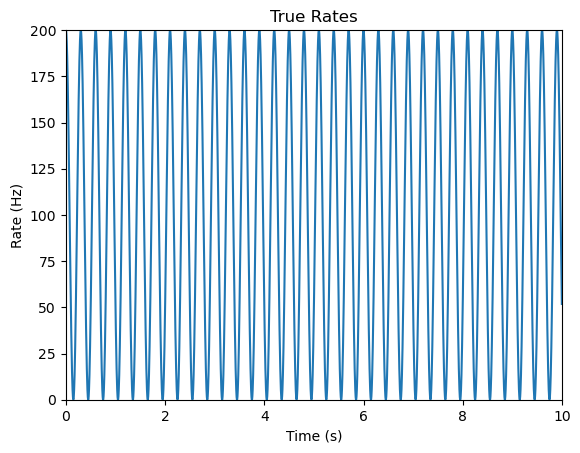

In [10]:
time_dependent_spikes = []
true_rates = []

for time in np.arange(0, T, dt):
    rate = 100 * (1 + np.cos(2*np.pi*time / 0.3))
    true_rates.append(rate)
    if np.random.rand() < rate * dt:
        time_dependent_spikes.append(time)

plt.figure(figsize=(10, 3))
plt.eventplot(
    time_dependent_spikes,
    colors='black',
    lineoffsets=0,
    linelengths=1,
    linewidths=0.3
)
plt.xlim(0, T)
plt.ylim(0, 1)
plt.yticks([])
plt.xlabel("Time (s)")
plt.title("Spike Train (Raster Plot)")
plt.tight_layout()
plt.show()



plt.figure()
plt.plot(np.arange(0, T, dt), true_rates)
plt.title("True Rates")
plt.ylabel("Rate (Hz)")
plt.xlabel("Time (s)")
plt.xlim(0,T)
plt.ylim(0,200)
plt.show()

### Rate Estimation

In [11]:
def estimate_rate(spikes, tau, dt, T):
    
    spike_indices = np.round(np.array(spikes) / dt).astype(int)
    spike_train = np.zeros(int(T / dt))
    spike_train[spike_indices] = True
    
    rates = []
    approximate_rate = 0
    for time in np.arange(0, T, dt):
        approximate_rate += dt * (-approximate_rate / tau)
        if spike_train[int(time / dt)]:
            approximate_rate += 1 / tau
        rates.append(approximate_rate)
    return rates

### Finding & Plotting Best Tau Value

Best Tau: 0.025


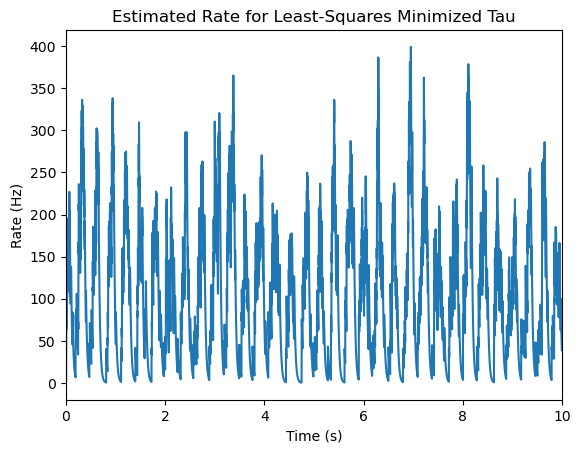

In [12]:
def square_error(data1, data2):
    sum = 0
    for index in range(len(data1)):
        sum += (data1[index] - data2[index]) ** 2
    return sum

least_error = float('inf')
best_tau = 0.001
for tau in np.arange(0.001, 0.1, 0.001):
    error = square_error(true_rates, estimate_rate(time_dependent_spikes, tau, dt, T))
    if error < least_error:
        least_error = error
        best_tau = tau

plt.figure()
estimated_rate = estimate_rate(time_dependent_spikes, best_tau, dt, T)
plt.plot(np.arange(0, T, dt), estimated_rate)
plt.title("Estimated Rate for Least-Squares Minimized Tau")
plt.xlabel("Time (s)")
plt.ylabel("Rate (Hz)")
plt.xlim(0, T)

print(f"Best Tau: {best_tau}")

## **Question 5**
**For a constant rate Poisson process, every specific (up to a finite resolution) sequence of N spikes occurring over a given time interval is equally likely. This seems paradoxical because we certainly do not expect to see all N spikes appearing within the first 1% of the time interval. Resolve this paradox.**

### Answer
Although it may be true that every specific sequence of N spikes over a given time interval is equally likely, there are simply far more sequences of N spikes over said interval that are more spread out. For example, if I have a bag of 50 differently colored marbles containing 10 colors of 5 marbles each, and I were forced to pick 10 at random, any sequence of marbles I pick is equally likely. It is equally likely that I pick 5 blue marbles and then 5 green marbles, as it is that I pick the marbles blue, green, yellow, pink, yellow, green... and so on. However, there are simply more combinations of the second sequence because the colors are different, allowing their positions to be switched, and the specific color also may not appear significant so long as it maintains a facade of diversity. In the same manner, Poisson generated spike trains will likely not yield absurd results such as all N spikes appearing in the first 1% of the interval because the number of combinations with the spikes more spread out vastly outnumbers the number of combinations where it doesn't.

## **Question 6**
**Build an approximate white-noise stimulus by choosing random values at discrete times separated by a time-step interval $\Delta t$. Plot its autocorrelation function and power spectrum (use the matlab® function spectrum or psd). Discuss how well this stimulus matches an ideal white-noise stimulus given the value of $\Delta t$ you used.**

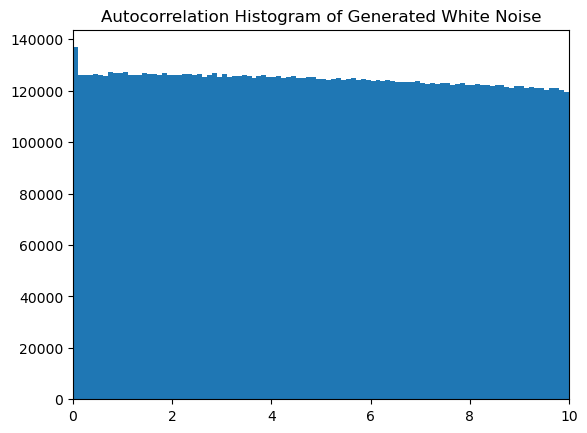

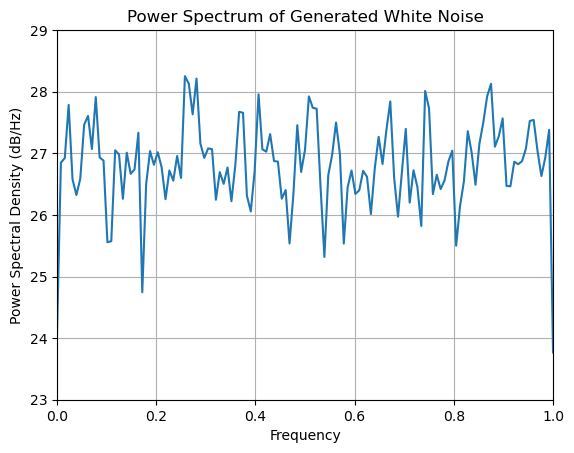

In [13]:
def generate_white_noise(T, dt, variance):
    return np.random.normal(scale=np.sqrt(variance / dt), size= int(T / dt))

white_noise = generate_white_noise(T, dt, variance=0.5)

plt.figure()
plt.hist(autocorrelation_histogram(white_noise), bins=100, range=(0,T))
plt.title("Autocorrelation Histogram of Generated White Noise")
plt.xlim(0, T)
plt.show()

plt.psd(white_noise)
plt.xlim(0, 1)
plt.title("Power Spectrum of Generated White Noise");

Ideal white noise would have a flat autocorrelation histogram, but the discrete nature of the calculations leads to higher autocorrelations of a lower value. Additionally, the ideal PSD function would be flat as well, and the generated approximation does remain concentrated around 20dB/Hz, barring fluctuations from the imaginary line due to non-ideality

## **Question 7**
**Consider a model with a firing rate determined in terms of a stimulus s(t) by integrating the equation $$\tau_r \frac{dr_{est}(t)}{dt} = [r0 + s]_+ - r_{est}(t)$$ where $r_0$ is a constant that determines the background firing rate and $\tau_r$ = 20 ms. Drive the model with an approximate white-noise stimulus. Adjust the amplitude of the white-noise and the parameter $r_0$ so that rectification is not a big effect (i.e. $r_0$ + s > 0 most of the time). From the responses of the model, compute the stimulus-response correlation function, $Q_{rs}$. Next, generate spikes from this model using a Poisson generator with a rate $r_{est}(t)$, and compute the spike-triggered average stimulus from the spike trains produced by the white-noise stimulus. By comparing the stimulus-response correlation function with the spike-triggered average, verify that equation 1.22 is satisfied. Examine what happens if you set $r_0$ = 0, so that the white-noise stimulus becomes half-wave rectified. $$ $$ For reference:
$$C(\tau) = \frac{1}{\langle r \rangle}Q_{rs}(-\tau) \tag{1.22}$$ where $C(\tau)$ is the spike-triggered average stimulus**

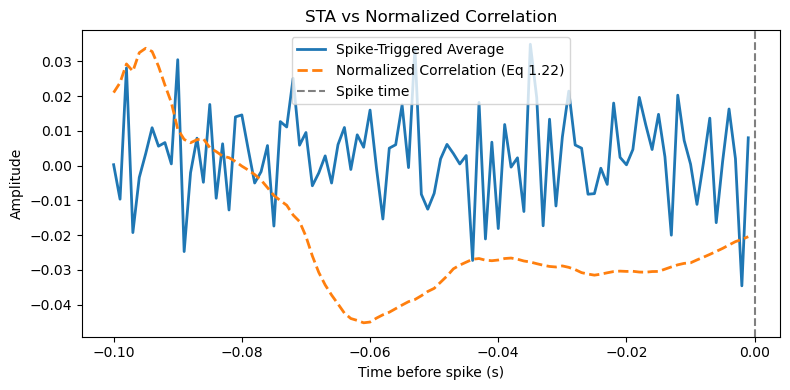

In [92]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
T = 10.0        # total time in seconds
dt = 0.001      # time step in seconds (1 ms)
time_points = int(T / dt)
window = 0.1    # STA window in seconds

# 1. Generate white noise stimulus
def generate_white_noise(T, dt, variance=0.2):
    n = int(T / dt)
    return np.random.normal(0, np.sqrt(variance), n)

stimulus = generate_white_noise(T, dt, variance=0.2)

# 2. Compute firing rate from stimulus with leaky integration and rectification
def response_rates(stimulus, r_0, tau, T, dt):
    rates = []
    current_rate = 0
    for i in range(len(stimulus)):
        current_rate += (dt / tau) * (max(0, r_0 + stimulus[i]) - current_rate)
        rates.append(current_rate)
    return np.array(rates)

r_0 = 100    # baseline firing rate
tau = 0.02   # 20 ms time constant
r_est = response_rates(stimulus, r_0, tau, T, dt)

# 3. Generate inhomogeneous Poisson spikes from rate r_est
def generate_poisson_spikes(rate, dt):
    spikes = []
    for i, r in enumerate(rate):
        p_spike = r * dt  # probability of spike in dt
        if np.random.rand() < p_spike:
            spikes.append(i * dt)
    return np.array(spikes)

inhomogenous_poisson = generate_poisson_spikes(r_est, dt)

# 4. Compute spike-triggered average (STA)
def sta(stimulus, spike_times, dt, window):
    stimulus = np.asarray(stimulus)
    spike_times = np.asarray(spike_times)
    max_lag = int(window / dt)
    sta_values = np.zeros(max_lag)
    count = 0
    for t_spike in spike_times:
        idx = int(np.round(t_spike / dt))
        if idx >= max_lag and idx < len(stimulus):
            sta_values += stimulus[idx - max_lag: idx]
            count += 1
    if count > 0:
        sta_values /= count
    taus = np.arange(-max_lag, 0) * dt  # negative lags leading up to spike
    return taus, sta_values

taus_sta, sta_values = sta(stimulus, inhomogenous_poisson, dt, window)

# 5. Compute stimulus-response correlation Qrs(τ)
def correlation(stimulus, response, T, dt):
    stimulus = np.asarray(stimulus)
    response = np.asarray(response)
    max_lag = int(T / dt)
    correlations = []
    for tau in range(-max_lag, max_lag):
        if tau < 0:
            s_shifted = stimulus[:tau]
            r_aligned = response[-tau:]
        elif tau > 0:
            s_shifted = stimulus[tau:]
            r_aligned = response[:-tau]
        else:
            s_shifted = stimulus
            r_aligned = response
        correlations.append(np.mean(s_shifted * r_aligned))
    return np.array(correlations)

Qrs = correlation(stimulus, r_est, T, dt)

# 6. Normalize and flip correlation to compare with STA (Eq 1.22)
r_mean = np.mean(r_est)
C_from_corr = Qrs[::-1] / r_mean  # flip time and normalize

# 7. Truncate correlation to match STA length
C_from_corr_window = C_from_corr[:len(sta_values)]

# 8. Plot STA and normalized correlation
plt.figure(figsize=(8, 4))
plt.plot(taus_sta, sta_values, label='Spike-Triggered Average', linewidth=2)
plt.plot(taus_sta, C_from_corr_window, label='Normalized Correlation (Eq 1.22)', linestyle='--', linewidth=2)
plt.axvline(0, color='gray', linestyle='--', label='Spike time')
plt.xlabel('Time before spike (s)')
plt.ylabel('Amplitude')
plt.title('STA vs Normalized Correlation')
plt.legend()
plt.tight_layout()
plt.show()

## Question 8